## Carregando os dados com a auxilio do pandas

In [6]:
# Primeiro deve rodar essa parte de codigo para o arquivo data.csv seja lido
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dados
df = pd.read_csv("../data/raw/data.csv")

# Remover a coluna id
df = df.drop(columns=["id"], errors="ignore")

# Remover colunas com mais de 40% de valores ausentes
threshold = 0.4
df = df.loc[:, df.isnull().mean() < threshold]

# Remove linhas duplicadas (integridade dos dados)
df = df.drop_duplicates()

# Visualizar primeiras linhas
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

# [1] Distribuição de classe

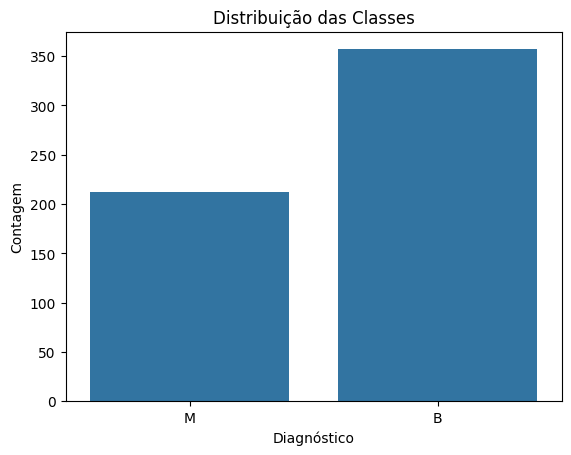

In [27]:
# [1] Gráfico em barras para mostrar a distribuição das classes (Maligno vs Benigno)
sns.countplot(x="diagnosis", data=df)  # conta quantos casos de cada diagnóstico existem no dataset
plt.title("Distribuição das Classes")   # título do gráfico
plt.xlabel("Diagnóstico")               # rótulo do eixo X: B = Benigno, M = Maligno
plt.ylabel("Contagem")                  # rótulo do eixo Y: número de casos
plt.show()                              # renderiza e exibe o gráfico

### [1] Interpretação — Distribuição das Classes

O dataset possui **357 casos benignos (~63%)** e **212 casos malignos (~37%)** — uma proporção desbalanceada.

**Por que isso importa:** um modelo que sempre chutasse "Benigno" teria 63% de accuracy sem aprender nada. É por isso que a métrica principal do projeto é o **Recall de Maligno**, não a Accuracy, logo queremos saber quantos casos malignos reais o modelo consegue detectar.

# [2] Variáveis mais influenciam o diagnóstico

In [28]:
# [2] Mostra quais variáveis mais influenciam o diagnóstico.
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})  # converte M/B para 1/0 para calcular correlação numérica

corr_target = df.corr()['diagnosis'].sort_values(ascending=False)  # correlação de cada feature com o target, do maior para o menor

print(corr_target)  # exibe o ranking completo — valores próximos de 1 indicam forte influência no diagnóstico

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

### [2] Interpretação — Correlação com o Diagnóstico

As features mais correlacionadas com malignidade descrevem **geometria irregular do tumor**:

| Feature | Correlação | Significado clínico |
|---|---|---|
| `concave points_worst` | 0.79 | Pontas côncavas mais pronunciadas no pior caso medido |
| `perimeter_worst` | 0.78 | Perímetro máximo maior em tumores malignos |
| `concave points_mean` | 0.78 | Irregularidade de borda consistente ao longo do tumor |
| `radius_worst` | 0.78 | Tamanho máximo maior em malignos |

Features com correlação próxima de zero (`smoothness_se`, `texture_se`, `fractal_dimension_mean`) praticamente não ajudam a distinguir as classes — o modelo aprende pouco com elas.

# [3] Heatmap de correlação entre as variáveis

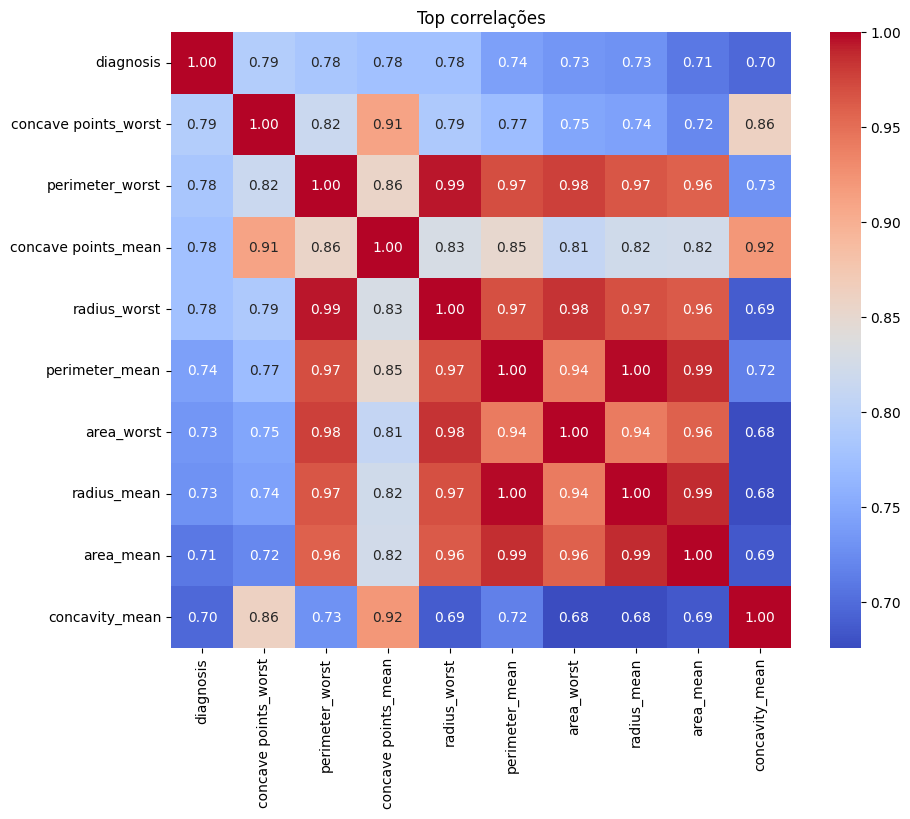

In [ ]:
# [3] Heatmap de correlação entre as variáveis numéricas mais importantes
top_features = corr_target.abs().sort_values(ascending=False).head(10).index  # seleciona as 10 features com maior correlação (em módulo) com o diagnóstico

corr_top = df[top_features].corr()  # calcula a correlação entre essas 10 features entre si (não com o target)

plt.figure(figsize=(10, 8))                                        # define o tamanho da figura em polegadas
sns.heatmap(corr_top, annot=True, cmap="coolwarm", fmt=".2f")     # plota o heatmap: vermelho = correlação positiva forte, azul = negativa
plt.title("Top correlações")                                       # título do gráfico
plt.show()                                                         # renderiza e exibe

### [3] Interpretação — Multicolinearidade entre as Top 10 Features

As 10 features mais correlacionadas com o diagnóstico são **também altamente correlacionadas entre si**. Por exemplo, `radius_worst` e `area_worst` têm correlação **~0.98** — geometricamente esperado (área = π × raio²).

**Implicação:** essas features quase duplicam a mesma informação. Para modelos lineares (Regressão Logística), isso pode causar instabilidade nos coeficientes. Para **Random Forest e Gradient Boosting**, não é problema — eles lidam bem com redundância de features e ainda conseguem identificar qual versão da mesma informação é mais útil em cada nó da árvore.

# [4] Pairplot


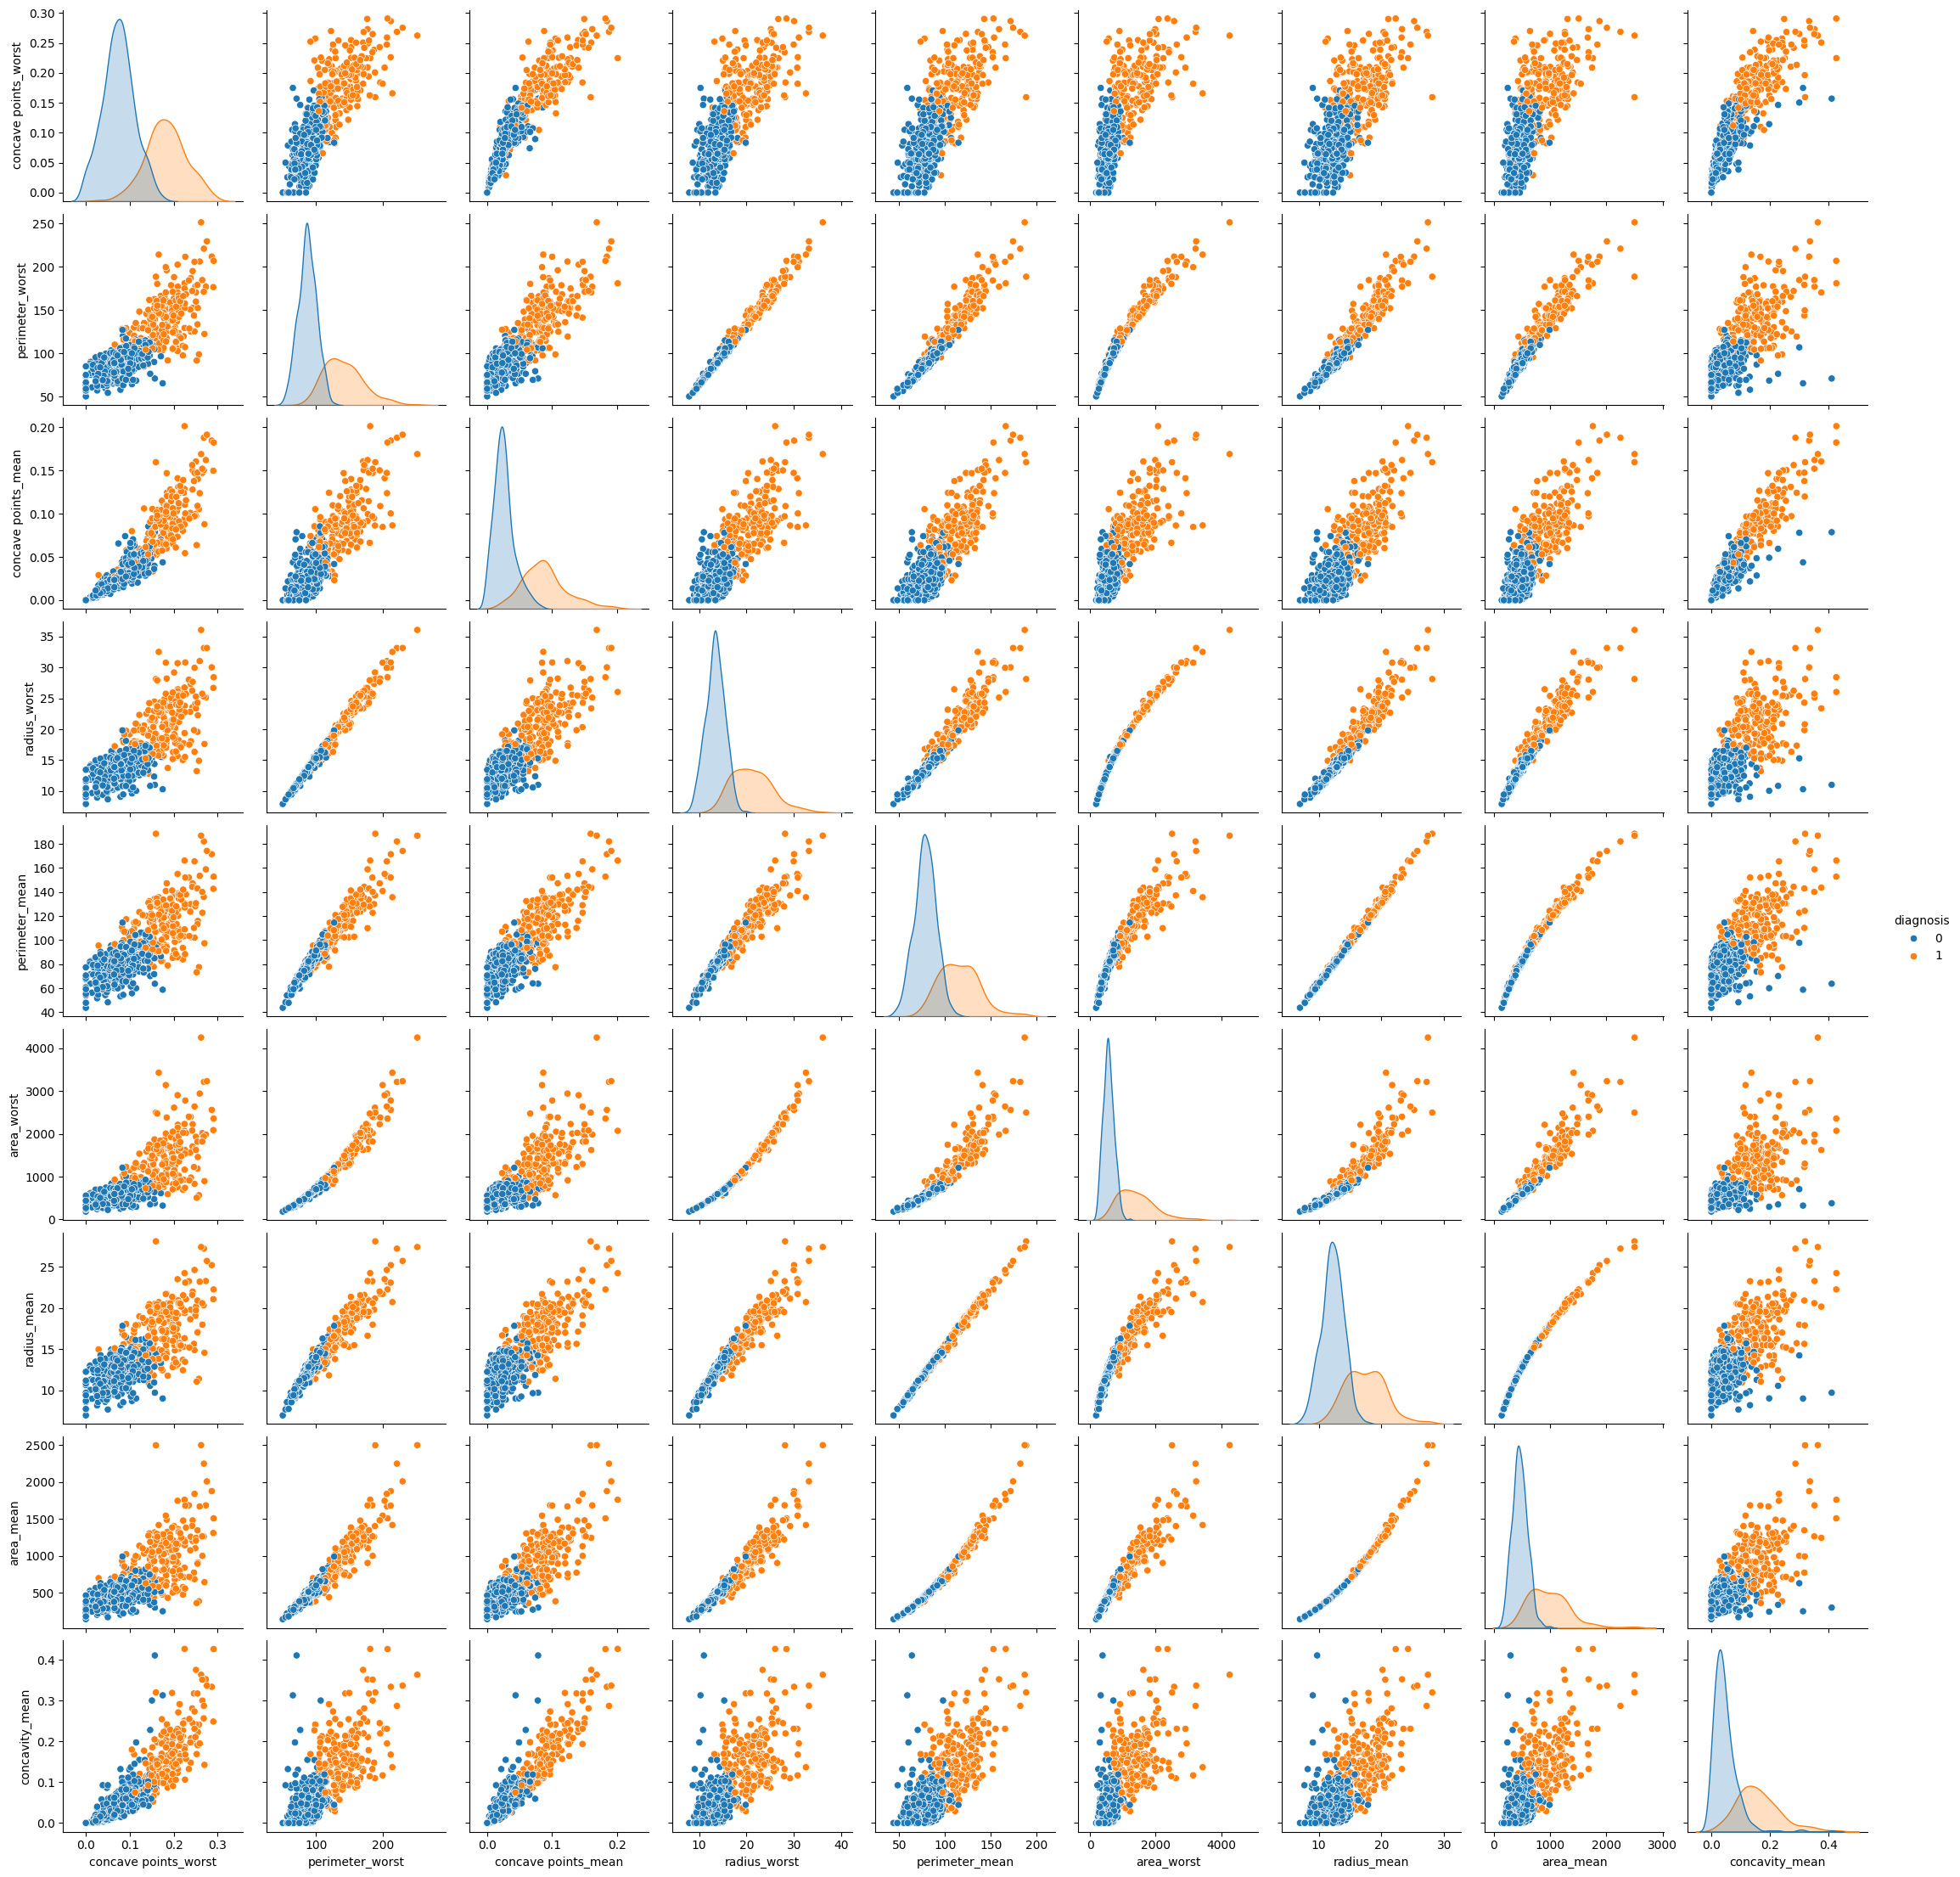

In [29]:
# [4] Pairplot — relações visuais entre as top features, coloridas por classe
sns.pairplot(df[top_features], hue='diagnosis')  # plota todos os pares de features: diagonal = distribuição individual, células = dispersão entre pares
plt.show()                                        # renderiza — pode demorar alguns segundos por gerar muitos subgráficos

### [4] Interpretação — Pairplot

Cada célula mostra a dispersão entre dois pares de features, colorindo Maligno (laranja) e Benigno (azul). A diagonal exibe a distribuição individual de cada feature.

**O que observar:** onde as nuvens de pontos das duas classes **não se sobrepõem**, aquele par de features consegue separar bem os diagnósticos. Features como `concave points_worst` e `perimeter_worst` mostram separação clara — as nuvens mal se tocam — confirmando seu alto poder preditivo identificado na correlação.

# [5] Distribuição por classe

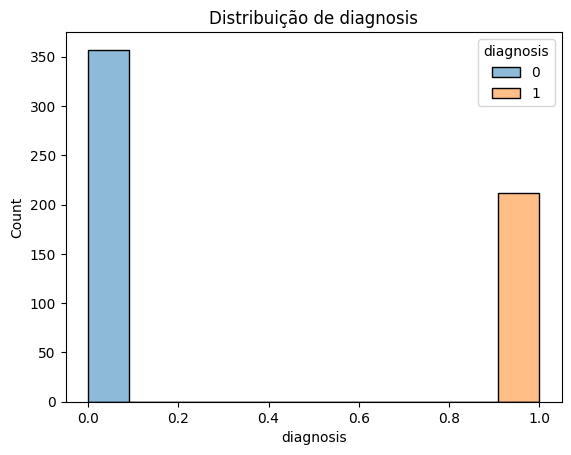

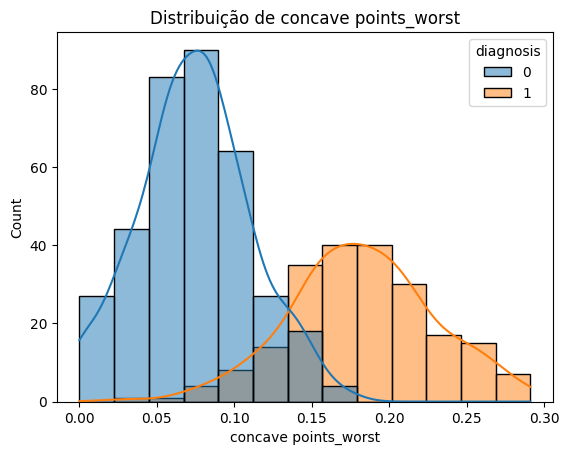

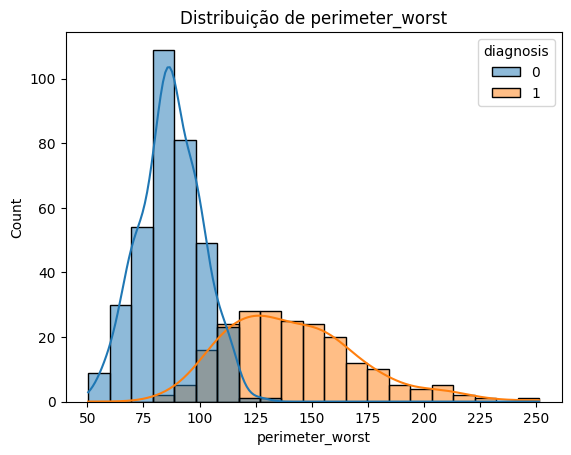

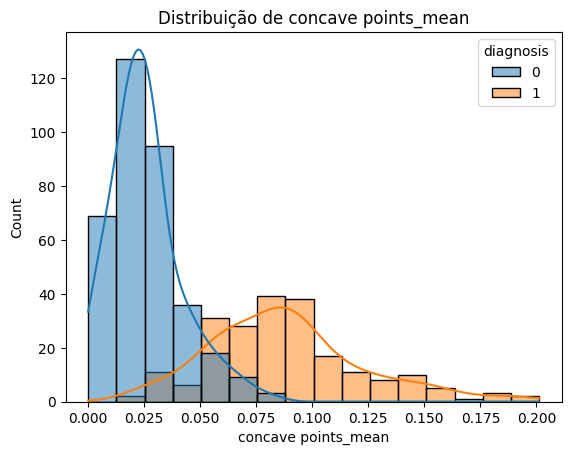

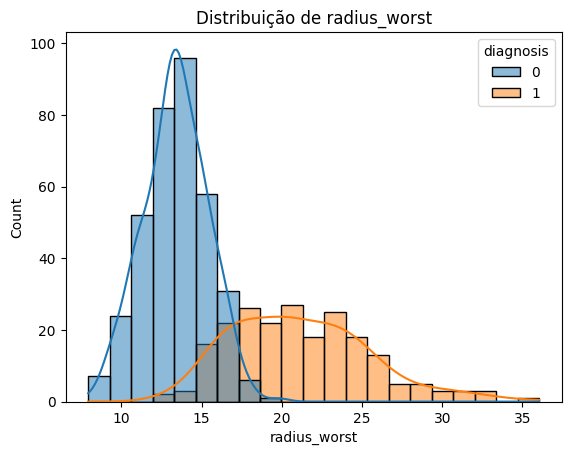

In [30]:
# [5] Distribuição por classe — como as variáveis se distribuem para Maligno vs Benigno
for col in top_features[:5]:                                              # itera sobre as 5 features mais importantes
    plt.figure()                                                           # cria uma figura separada para cada feature
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True)               # histograma com curva KDE (suavização), separado por classe (hue)
    plt.title(f'Distribuição de {col}')                                    # título com o nome da feature atual
    plt.show()                                                             # renderiza e exibe cada gráfico

### [5] Interpretação — Distribuição por Classe (Histogramas)

Para cada feature, a curva de Malignos e Benignos mostra onde os valores se concentram. A linha suavizada (KDE) facilita ver o formato da distribuição.

- **Pouca sobreposição entre as curvas** → a feature consegue separar bem as classes sozinha
- **Muita sobreposição** → a feature sozinha não basta — o modelo precisa combinar várias

Na prática, `concave points_worst` e `radius_worst` apresentam curvas bem separadas, com Malignos deslocados para valores maiores. Isso confirma que tumores malignos tendem a ser maiores e mais irregulares do que benignos.

# [6] Boxplot por classe

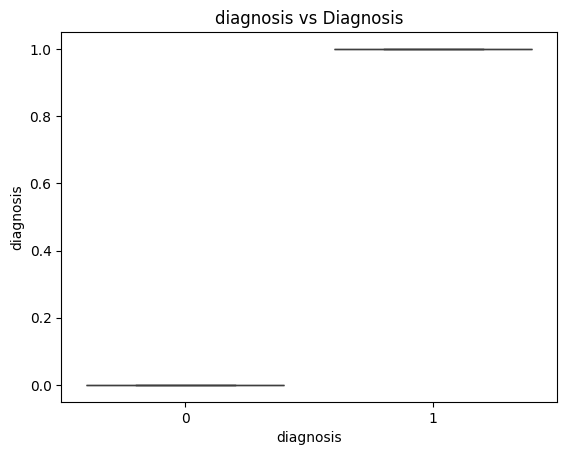

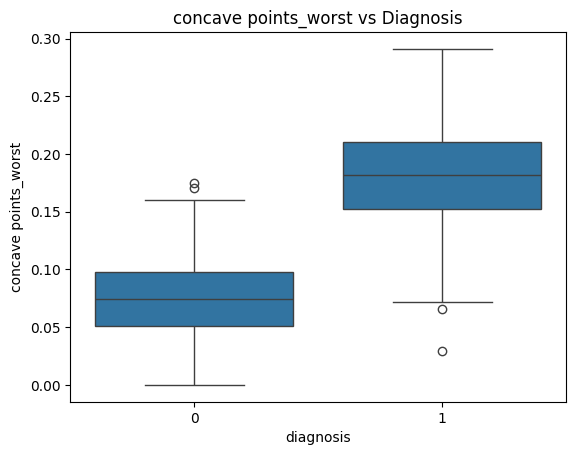

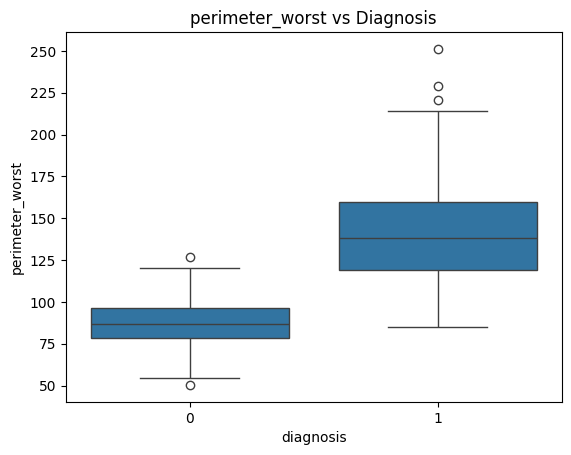

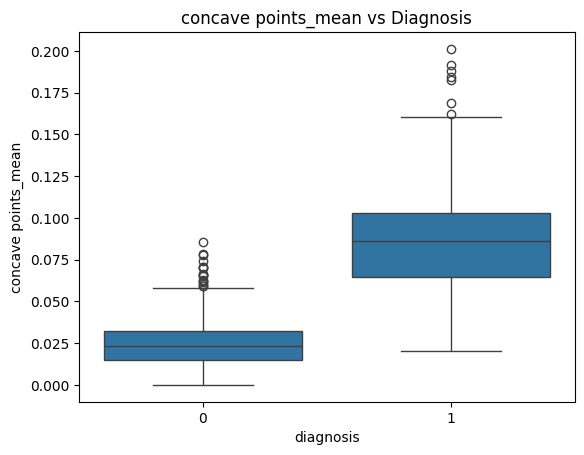

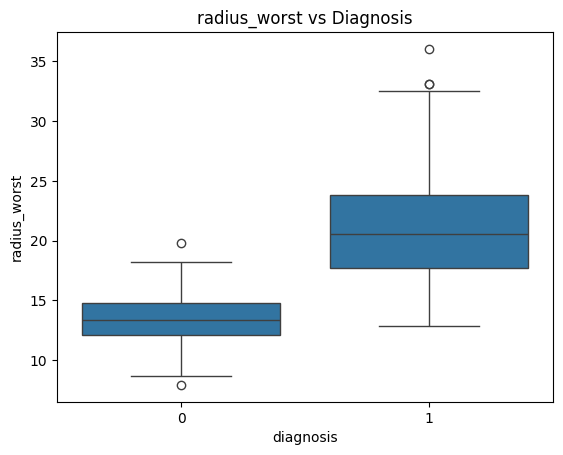

In [31]:
# [6] Boxplot por classe — distribuição estatística de cada feature separada por diagnóstico
for col in top_features[:5]:                        # itera sobre as 5 features mais importantes
    plt.figure()                                     # cria uma figura separada para cada feature
    sns.boxplot(x='diagnosis', y=col, data=df)       # boxplot: linha central = mediana, caixa = 50% dos dados, pontos = outliers
    plt.title(f'{col} vs Diagnosis')                 # título com o nome da feature atual
    plt.show()                                       # renderiza e exibe

### [6] Interpretação — Boxplot por Classe

Cada boxplot mostra a distribuição estatística separada por Benigno (0) e Maligno (1): a linha central é a mediana, a caixa cobre 50% dos dados, e os pontos fora são outliers.

**O que os dados revelam:**
- A **mediana** de Malignos é consistentemente maior em todas as 5 features — tumores malignos são maiores e mais irregulares
- A **caixa** de Malignos é mais larga — maior variabilidade dentro da própria classe maligna (tumores malignos variam mais entre si)
- Os **outliers superiores** em Malignos representam casos extremos de tumores muito grandes ou muito irregulares

O boxplot complementa o histograma: onde o histograma mostra a forma da distribuição, o boxplot destaca a mediana e os casos extremos.

# [7] Detecta multicolinearidade

In [32]:
# [7] Detecta multicolinearidade — quais variáveis são altamente correlacionadas entre si
import numpy as np
corr = df.select_dtypes(include=[np.number]).corr()  # matriz de correlação entre todas as features numéricas
high_corr = corr.abs() > 0.9                          # máscara booleana: True onde correlação é maior que 90%

print(high_corr.sum().sort_values(ascending=False))   # para cada feature, conta quantas outras têm correlação > 0.9 com ela — quanto maior, mais redundante

radius_mean                6
area_mean                  6
perimeter_mean             6
perimeter_worst            6
area_worst                 6
radius_worst               6
radius_se                  3
area_se                    3
perimeter_se               3
concave points_mean        3
concavity_mean             2
texture_worst              2
texture_mean               2
concave points_worst       2
diagnosis                  1
texture_se                 1
fractal_dimension_mean     1
symmetry_mean              1
compactness_mean           1
smoothness_mean            1
concave points_se          1
smoothness_se              1
compactness_se             1
symmetry_se                1
fractal_dimension_se       1
concavity_se               1
smoothness_worst           1
compactness_worst          1
concavity_worst            1
symmetry_worst             1
fractal_dimension_worst    1
dtype: int64


### [7] Interpretação — Detecção de Multicolinearidade

`radius_mean`, `area_mean` e `perimeter_mean` têm **6 outras features com correlação > 0.9** cada uma — são matematicamente quase a mesma variável. Isso faz sentido geometricamente: área = π × raio², perímetro ≈ 2π × raio. As versões `_mean`, `_se` e `_worst` de cada medida também tendem a se correlacionar.

**Implicação prática:** se o objetivo fosse reduzir o número de features (com PCA ou seleção de features), poderíamos eliminar várias redundantes sem perder poder preditivo. Para os modelos atuais baseados em árvore (Random Forest, Gradient Boosting), essa redundância não prejudica o desempenho.

# [8] Heatmap triangular

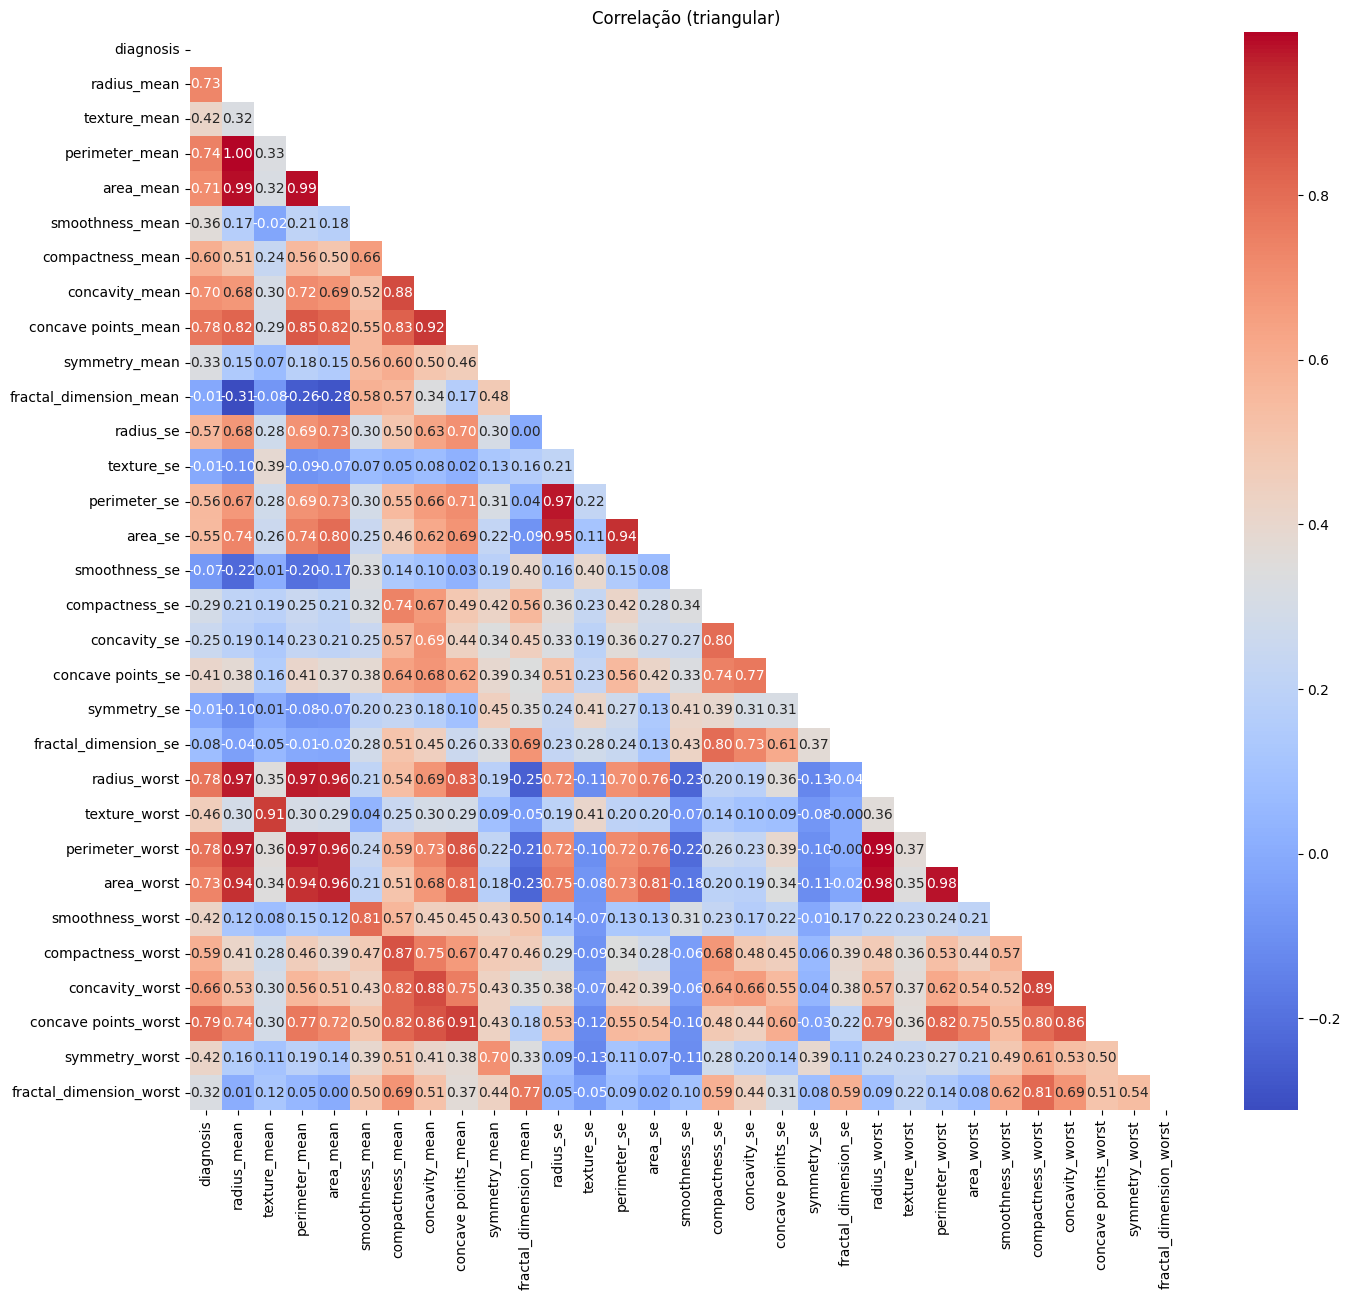

In [ ]:
# [8] Heatmap triangular
mask = np.triu(np.ones_like(corr, dtype=bool))  # cria máscara para ocultar a metade inferior (que é espelho da superior)

plt.figure(figsize=(16, 14))                                                    # figura grande para acomodar as 30 features
sns.heatmap(corr, mask=mask, cmap="coolwarm", annot=True, fmt=".2f")           # plota apenas a metade superior — vermelho = positiva, azul = negativa
plt.title("Correlação (triangular)")                                            # título do gráfico
plt.show()                                                                      # renderiza e exibe

### [8] Interpretação — Heatmap Triangular de Correlação

Versão mais limpa da matriz de correlação completa — exibe apenas a metade superior para evitar a repetição espelhada dos valores.

**Como ler:** cores **vermelhas** = correlação positiva forte (as duas features crescem juntas); cores **azuis** = correlação negativa (quando uma sobe, a outra cai); **branco** = sem correlação. Os clusters vermelhos intensos entre `radius`, `area` e `perimeter` (nas versões `_mean` e `_worst`) confirmam a alta multicolinearidade identificada na análise anterior — são redundantes entre si, mas altamente preditivos para o diagnóstico.